In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL, MSTL, DecomposeResult

from sktime.transformations.series.vmd import VmdTransformer

In [2]:
df = pd.read_csv('../data/raw/dataset_2019_2025.csv')
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
print(df.shape)
df.head()

(52608, 39)


,datetime,precipitation,cloud_cover,sunshine,temperature,relative_humidity,price,nuclear,hydro_run_of_river,biomass,...,czech_republic_cbet,denmark_cbet,france_cbet,luxembourg_cbet,netherlands_cbet,norway_cbet,poland_cbet,sweden_cbet,switzerland_cbet,sum_cbet
0,2019-01-01 00:00:00+00:00,0.000,93.5,NaN,7.250,87.25,10.07,8040.8,1752.9,4740.5,...,-0.710,-0.183,-3.642,-0.360,-1.176,NaN,0.0,-0.076,-0.8,-11.211
1,2019-01-01 01:00:00+00:00,0.000,100.0,NaN,7.175,85.00,-4.08,7562.4,1751.9,4724.0,...,-1.100,-0.307,-3.083,-0.350,-1.428,NaN,0.0,-0.067,-0.8,-11.405
2,2019-01-01 02:00:00+00:00,0.025,100.0,0.0,6.875,87.75,-9.91,7079.6,1759.8,4723.7,...,-1.137,-0.412,-3.130,-0.344,-1.492,NaN,0.0,-0.067,-0.8,-12.343
3,2019-01-01 03:00:00+00:00,0.050,100.0,0.0,6.625,90.50,-7.41,7117.7,1661.4,4731.7,...,-1.100,-0.676,-4.060,-0.360,-0.862,NaN,0.0,-0.067,-0.8,-12.910
4,2019-01-01 04:00:00+00:00,0.100,100.0,0.0,6.450,90.50,-12.55,7027.8,1677.3,4729.2,...,-1.000,-1.441,-4.641,-0.336,-0.844,NaN,0.0,-0.067,-0.8,-13.946


In [3]:
df_2025 = df[df['datetime'].dt.year == 2024]
print(df_2025.shape)
df_2025.head()

(8784, 39)


,datetime,precipitation,cloud_cover,sunshine,temperature,relative_humidity,price,nuclear,hydro_run_of_river,biomass,...,czech_republic_cbet,denmark_cbet,france_cbet,luxembourg_cbet,netherlands_cbet,norway_cbet,poland_cbet,sweden_cbet,switzerland_cbet,sum_cbet
43824,2024-01-01 00:00:00+00:00,0.00,96.75,0.0,6.250,77.75,0.01,NaN,2370.4,4041.2,...,-0.826,-3.500,-0.732,-0.186,-0.309,-1.4,-0.773,-0.519,-0.796,-11.650
43825,2024-01-01 01:00:00+00:00,0.00,100.00,0.0,6.125,77.25,0.00,NaN,2371.4,4011.2,...,-0.894,-3.458,-1.214,-0.182,-0.157,-1.4,-0.847,-0.519,-0.800,-11.493
43826,2024-01-01 02:00:00+00:00,0.25,81.00,0.0,5.575,81.50,-0.01,NaN,2344.2,4013.5,...,-0.607,-3.398,-1.900,-0.184,0.582,-1.4,-0.915,-0.519,-0.794,-10.616
43827,2024-01-01 03:00:00+00:00,0.15,56.25,0.0,5.750,79.75,-0.03,NaN,2347.4,4044.1,...,-0.737,-3.000,-2.900,-0.194,0.230,-1.4,-0.896,-0.519,-0.800,-11.426
43828,2024-01-01 04:00:00+00:00,0.00,74.75,0.0,6.150,77.25,-0.02,NaN,2333.7,4104.8,...,-0.654,-3.090,-0.548,-0.194,-0.857,-1.4,-0.772,-0.519,-0.799,-10.642


In [4]:
stl = MSTL(df_2025['price'], periods=[24, 24*7], stl_kwargs={'robust':True})
res = stl.fit()

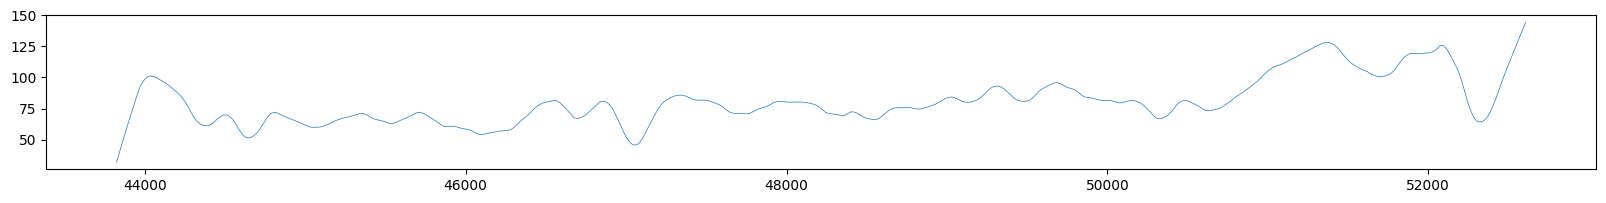

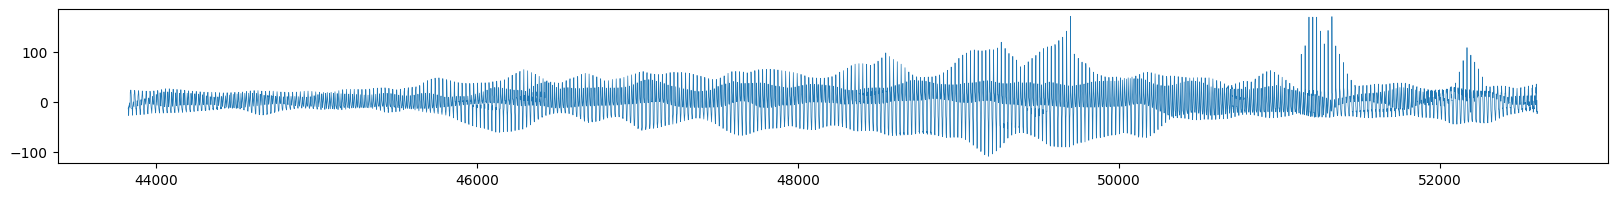

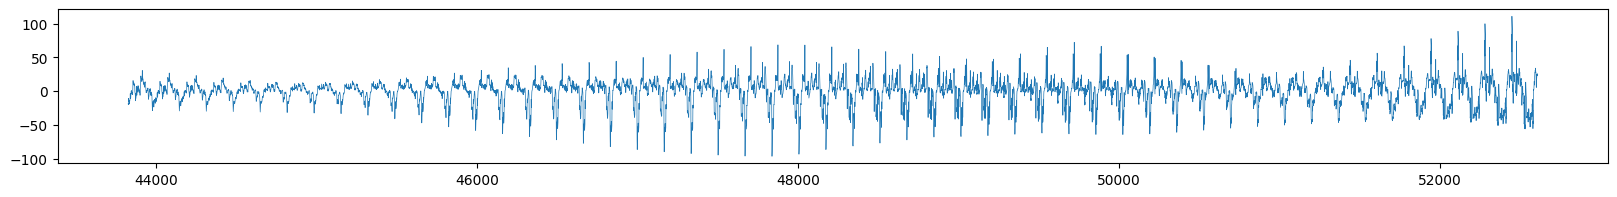

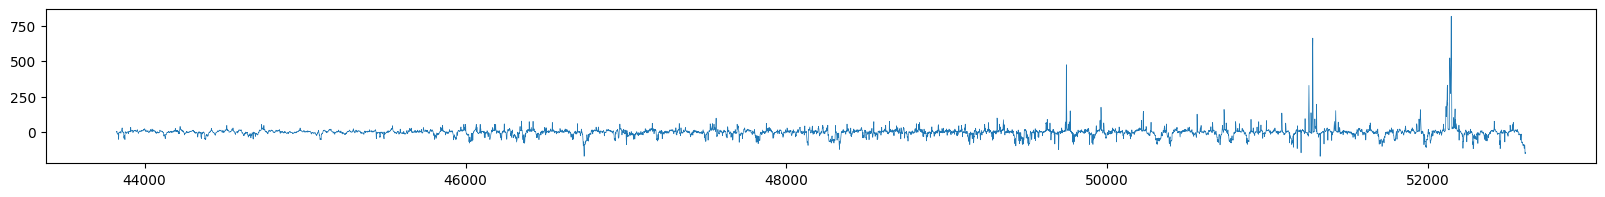

In [5]:
for comp in (res.trend, res.seasonal.iloc[:, 0], res.seasonal.iloc[:, 1], res.resid):
    fig, ax = plt.subplots(figsize=(20, 2))
    ax.plot(comp, linewidth=0.5)
    plt.show()

In [73]:
# fig, ax = plt.subplots(figsize=(20, 5))
# ax.plot(df_2025['price'], linewidth=0.5, c='blue')
# ax.plot(res.trend+res.resid, linewidth=0.5, c='red')
# ax.plot(res.seasonal.sum(axis=1), linewidth=0.5, c='green')
# plt.show()

In [74]:
vmd = VmdTransformer(K=12, alpha=4000)
df_vmd = vmd.fit_transform(df['price'])

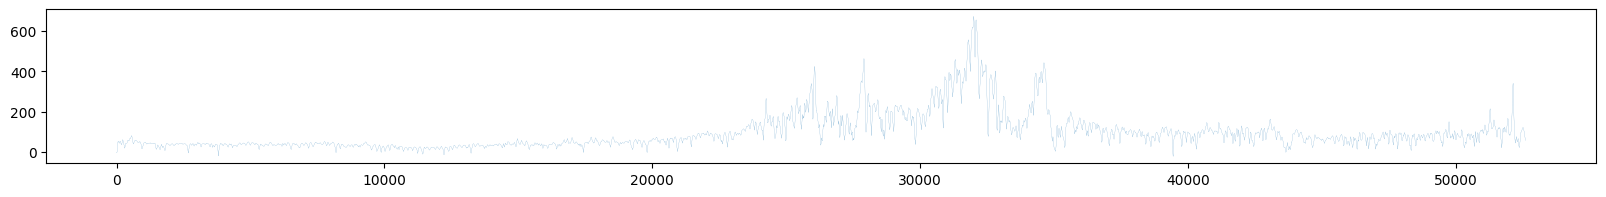

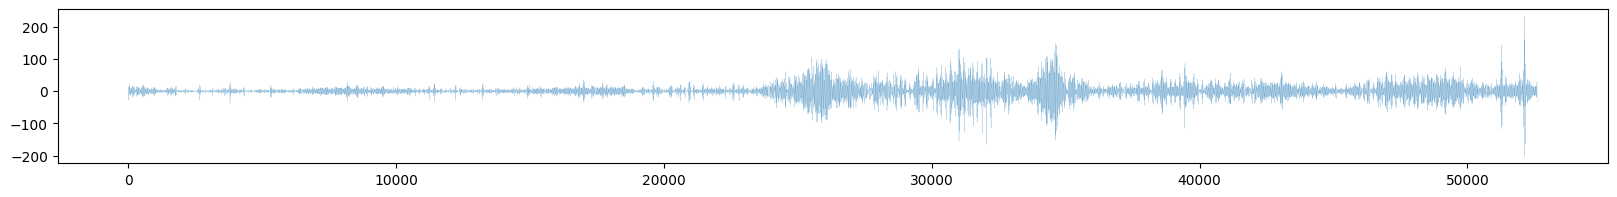

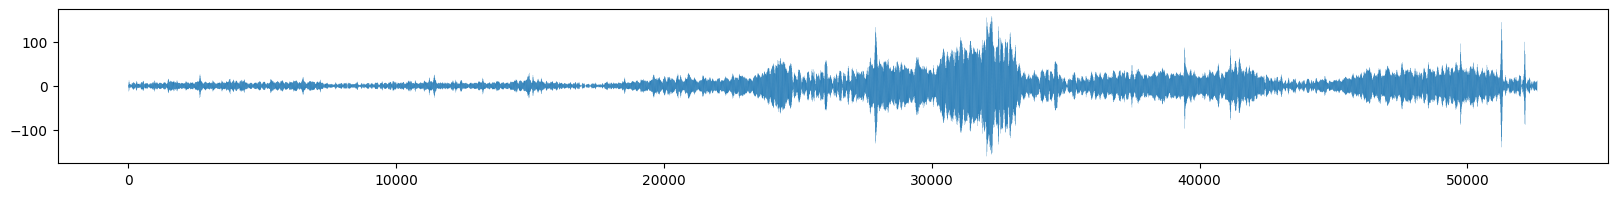

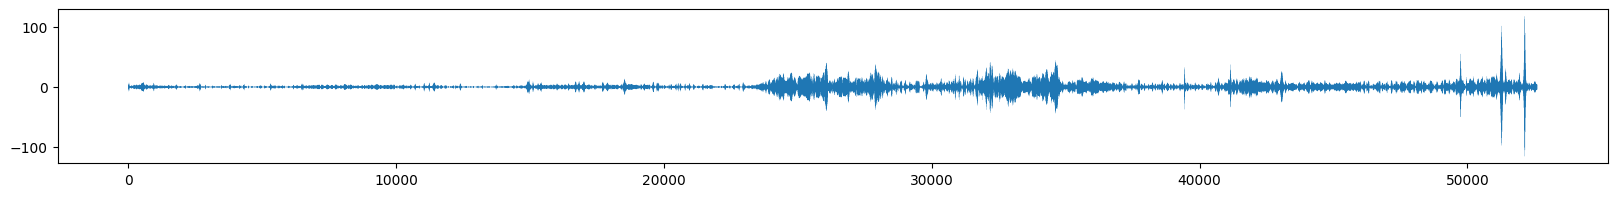

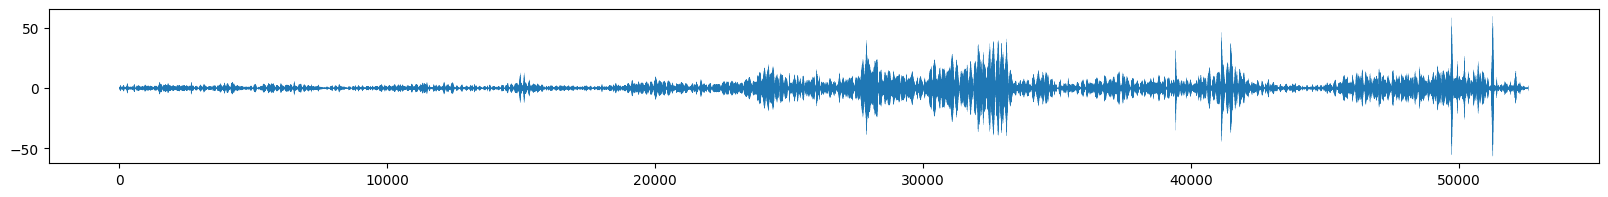

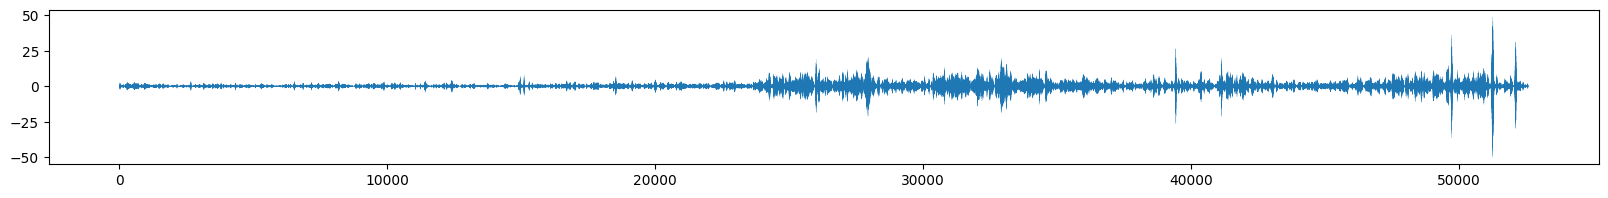

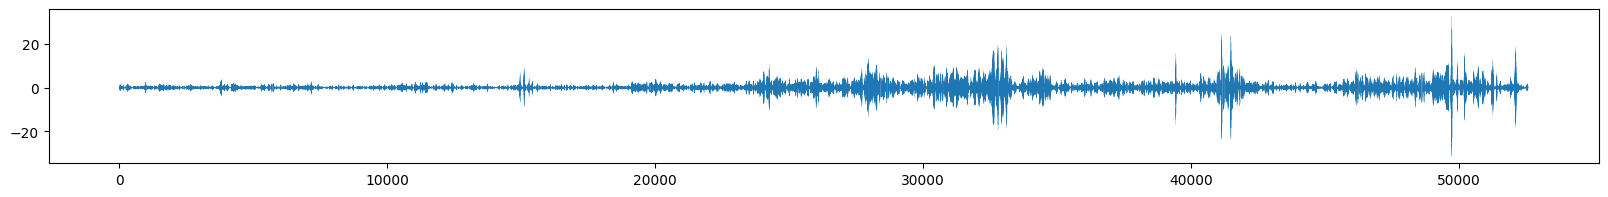

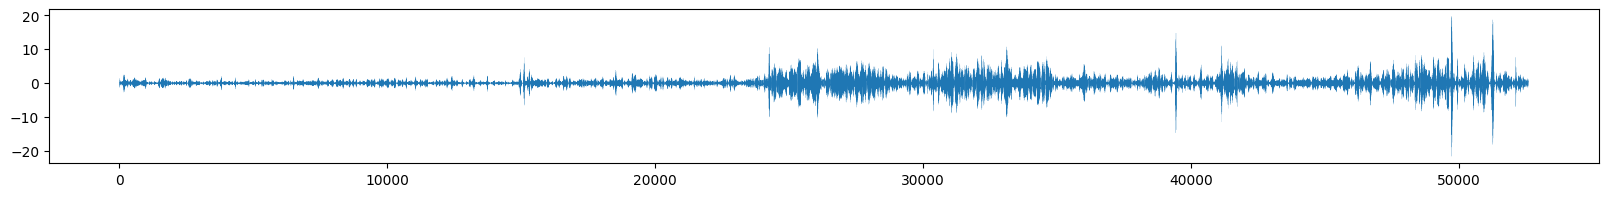

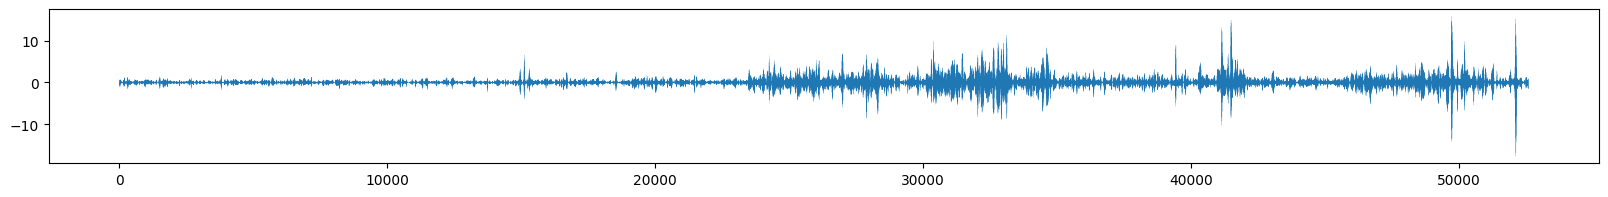

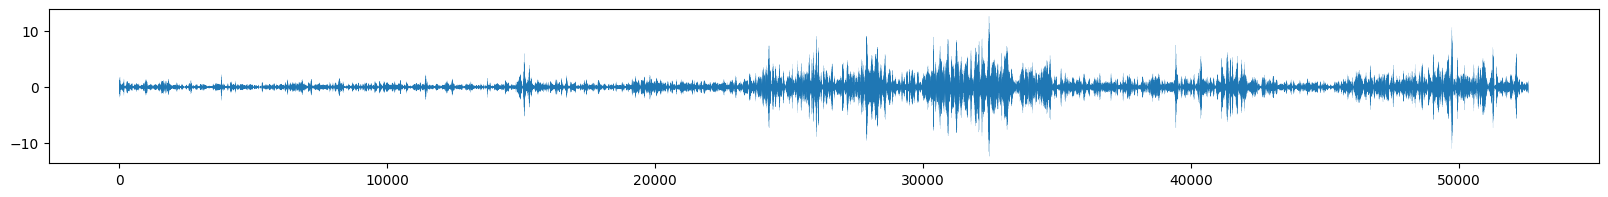

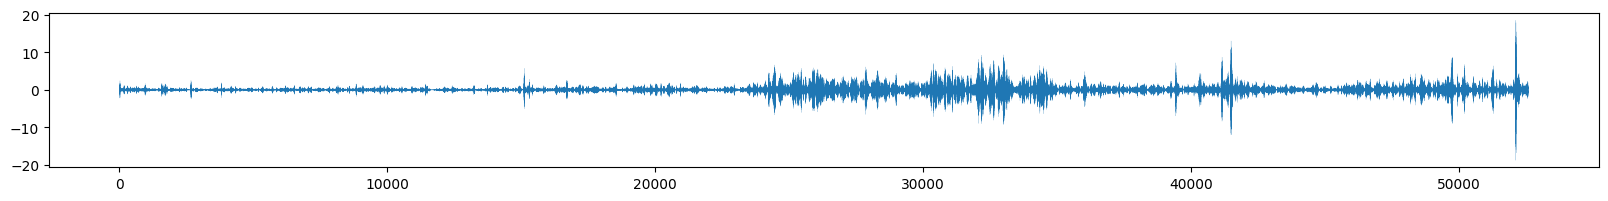

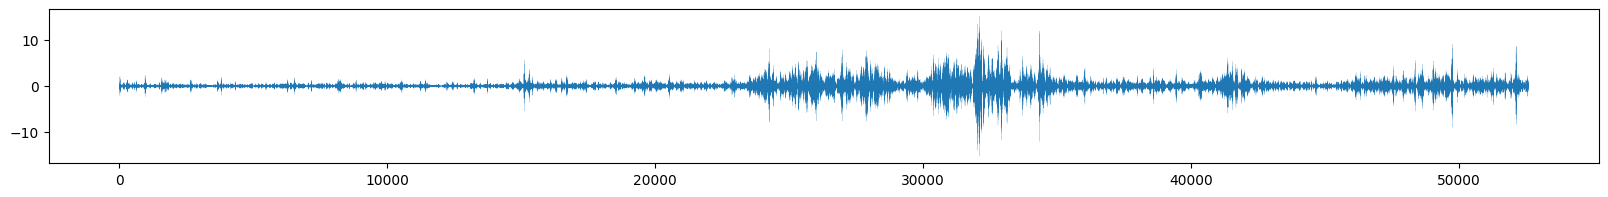

In [76]:
for col in df_vmd.columns:
    fig, ax = plt.subplots(figsize=(20, 2))
    ax.plot(df_vmd[col], linewidth=0.1)
    plt.show()

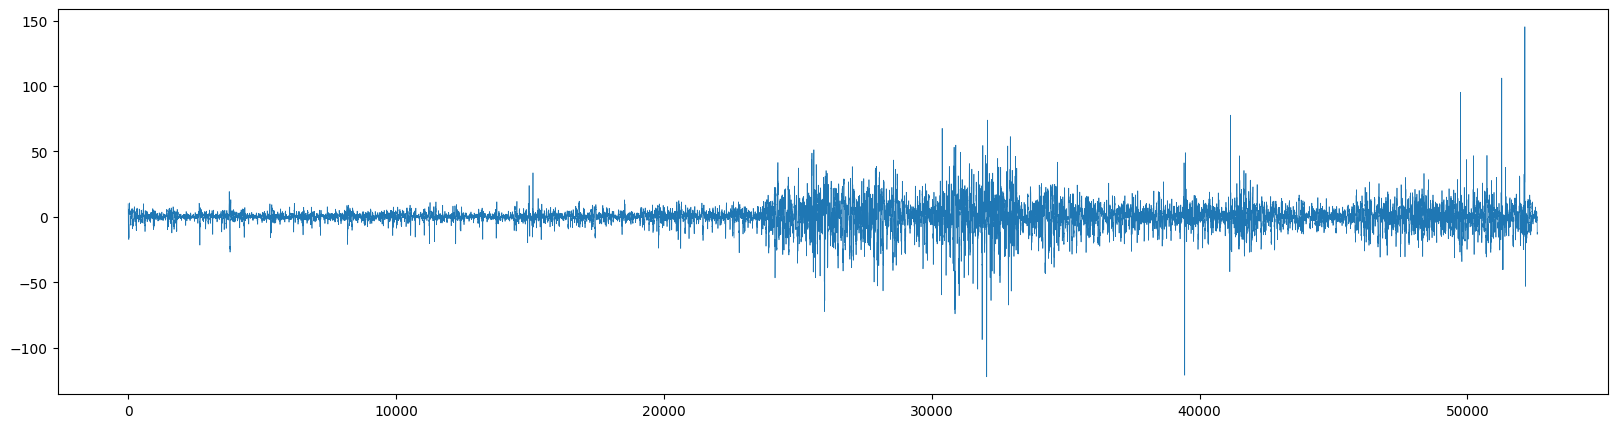

In [77]:
resid = df['price'].to_numpy() - df_vmd.sum(axis=1).to_numpy()
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(resid, linewidth=0.5)
plt.show()

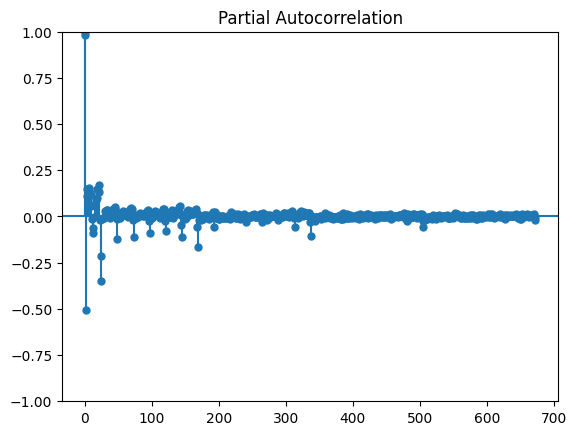

In [8]:
plot_pacf(df['price'], lags=24*7*4)
plt.show()

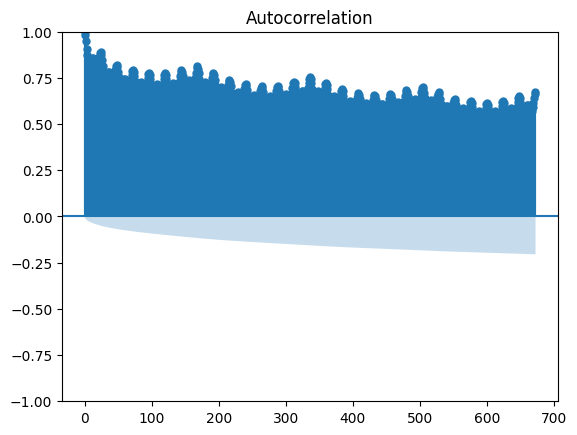

In [9]:
plot_acf(df['price'], lags=24*7*4)
plt.show()